# Heart Disease Prediction - Machine Learning Project

# Hamza Sheikh(24L-2500)
# Abuzar Rizwan(24L-2535)
# Sadeem Arshad(24L-2502)
**Dataset:** CDC BRFSS 2015 Heart Disease Dataset (253,680 samples) 

**Goal:** Predict heart disease with 80%+ recall using Random Forest



## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
import pickle
import streamlit as st
import os

print("All libraries imported successfully!")

All libraries imported successfully!


## Load & Explore Data

In [3]:
df = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv')

print("="*80)
print(" "*30 + "DATASET OVERVIEW")
print("="*80)
print(f"\nShape: {df.shape[0]:,} rows X {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

                              DATASET OVERVIEW

Shape: 253,680 rows X 22 columns

Columns: ['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [4]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null 

In [6]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.094186,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.296921,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.292087,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.698160,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [7]:
# Missing values check
print("="*80)
print("MISSING VALUES CHECK")
print("="*80)
missing = df.isnull().sum()
print(f"\nTotal missing values: {missing.sum()}")
if missing.sum() == 0:
    print("No missing values found!")

MISSING VALUES CHECK

Total missing values: 0
No missing values found!


In [8]:
print("="*80)
print("TARGET VARIABLE: HeartDiseaseorAttack")
print("="*80)

print("\nValue Counts:")
print(df['HeartDiseaseorAttack'].value_counts())

print("\nPercentage:")
print(df['HeartDiseaseorAttack'].value_counts(normalize=True) * 100)

target_counts = df['HeartDiseaseorAttack'].value_counts()
print(f"\nClass Imbalance Ratio: {target_counts[0]/target_counts[1]:.1f}:1")
print("    We'll use UNDERSAMPLING to balance classes")

TARGET VARIABLE: HeartDiseaseorAttack

Value Counts:
HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64

Percentage:
HeartDiseaseorAttack
0.0    90.581441
1.0     9.418559
Name: proportion, dtype: float64

Class Imbalance Ratio: 9.6:1
    We'll use UNDERSAMPLING to balance classes


## Data Visualizations/EDA

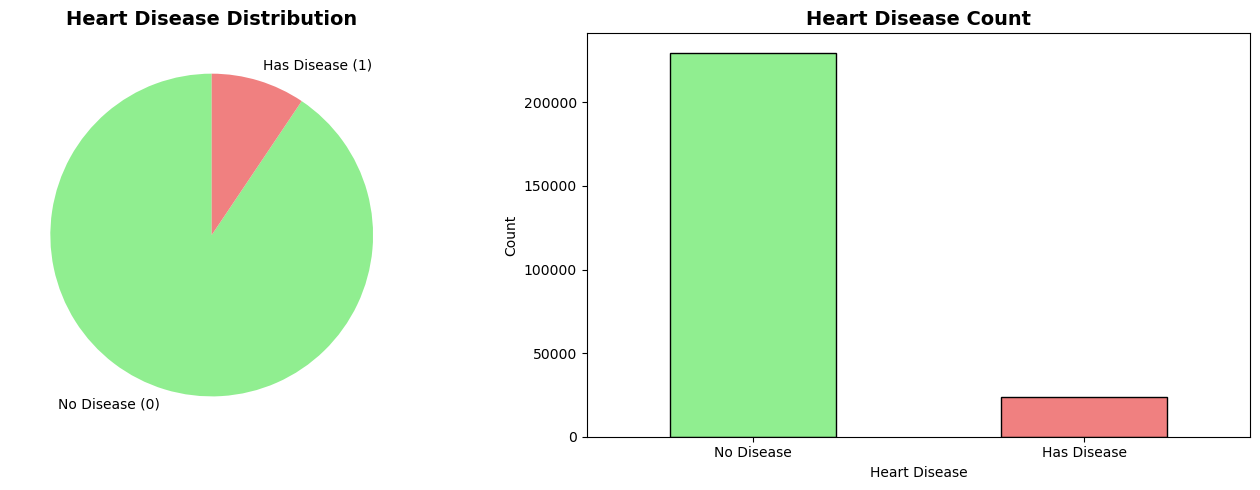

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(df['HeartDiseaseorAttack'].value_counts(),
           labels=['No Disease (0)', 'Has Disease (1)'],
           startangle=90, colors=['lightgreen', 'lightcoral'])
axes[0].set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')

target_counts.plot(kind='bar', ax=axes[1], color=['lightgreen', 'lightcoral'], edgecolor='black')
axes[1].set_title('Heart Disease Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Heart Disease')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['No Disease', 'Has Disease'], rotation=0)

plt.tight_layout()
plt.show()

C:\Users\Sadeem\AppData\Local\Temp\ipykernel_11048\3355120398.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
C:\Users\Sadeem\AppData\Local\Temp\ipykernel_11048\3355120398.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


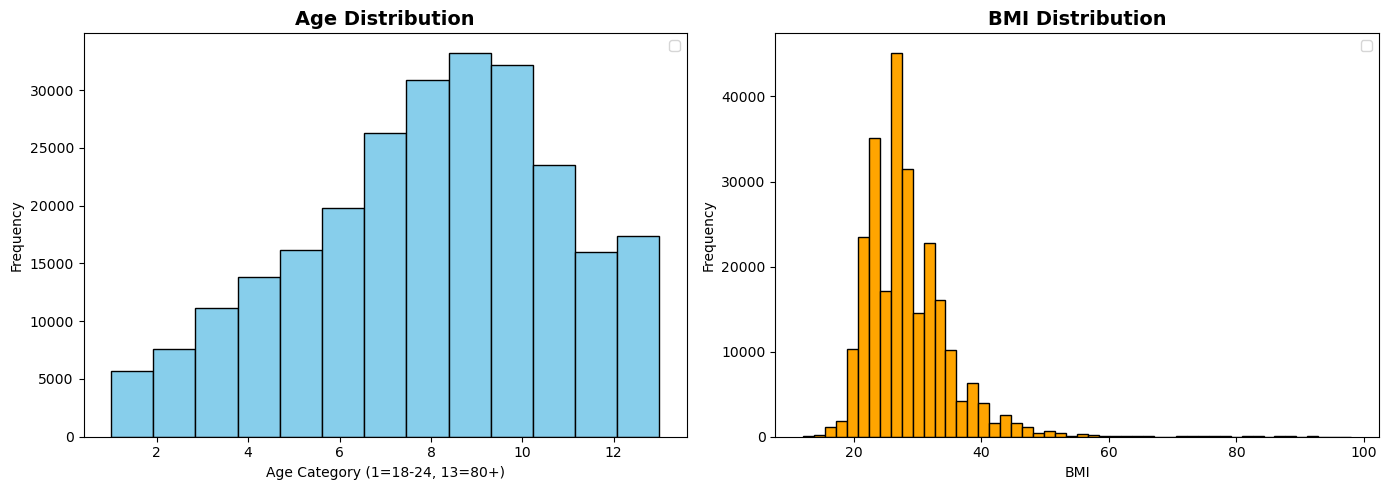

In [10]:
# age and bmi distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Age'], bins=13, edgecolor='black', color='skyblue')
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Category (1=18-24, 13=80+)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['BMI'], bins=50, edgecolor='black', color='orange')
axes[1].set_title('BMI Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

Disease Rate by Age Category:
      Total    Sick  Disease_Rate
Age                              
1.0    5700    29.0      0.508772
2.0    7598    54.0      0.710713
3.0   11123   126.0      1.132788
4.0   13823   193.0      1.396224
5.0   16157   351.0      2.172433
6.0   19819   712.0      3.592512
7.0   26314  1425.0      5.415368
8.0   30832  2253.0      7.307343
9.0   33244  3358.0     10.101071
10.0  32194  4193.0     13.024166
11.0  23533  3947.0     16.772192
12.0  15980  3093.0     19.355444
13.0  17363  4159.0     23.953234


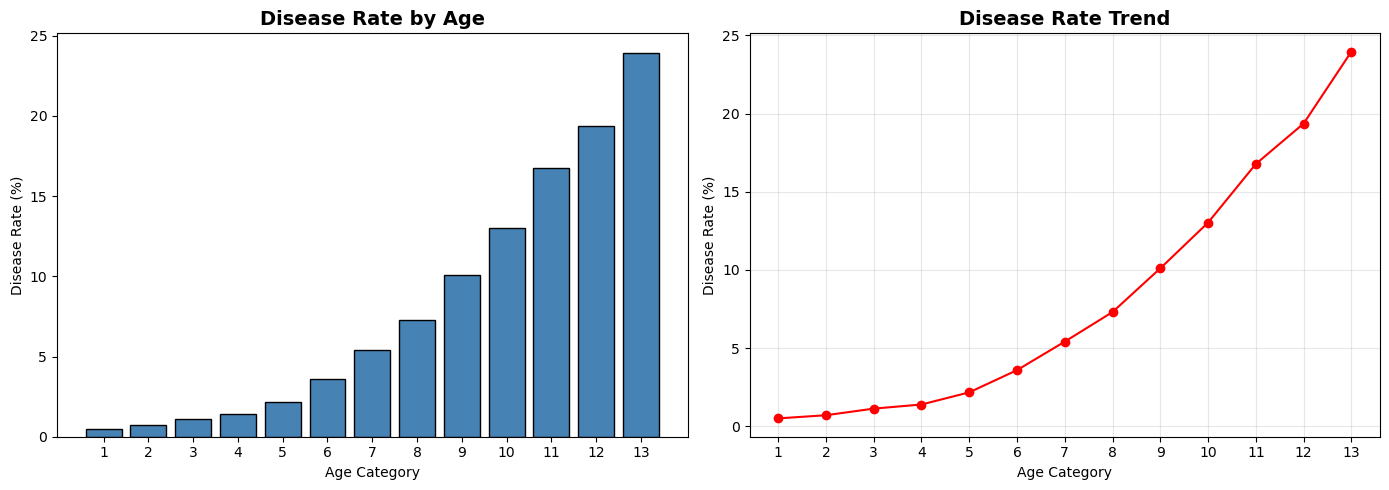

In [11]:
# disease rate by Age
age_disease = df.groupby('Age')['HeartDiseaseorAttack'].agg(['count', 'sum', 'mean'])
age_disease.columns = ['Total', 'Sick', 'Disease_Rate']
age_disease['Disease_Rate'] *= 100

print("Disease Rate by Age Category:")
print(age_disease)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(age_disease.index, age_disease['Disease_Rate'], color='steelblue', edgecolor='black')
axes[0].set_title('Disease Rate by Age', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Category')
axes[0].set_ylabel('Disease Rate (%)')
axes[0].set_xticks(age_disease.index)

axes[1].plot(age_disease.index, age_disease['Disease_Rate'], marker='o', color='red')
axes[1].set_title('Disease Rate Trend', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Category')
axes[1].set_ylabel('Disease Rate (%)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(age_disease.index)

plt.tight_layout()
plt.show()

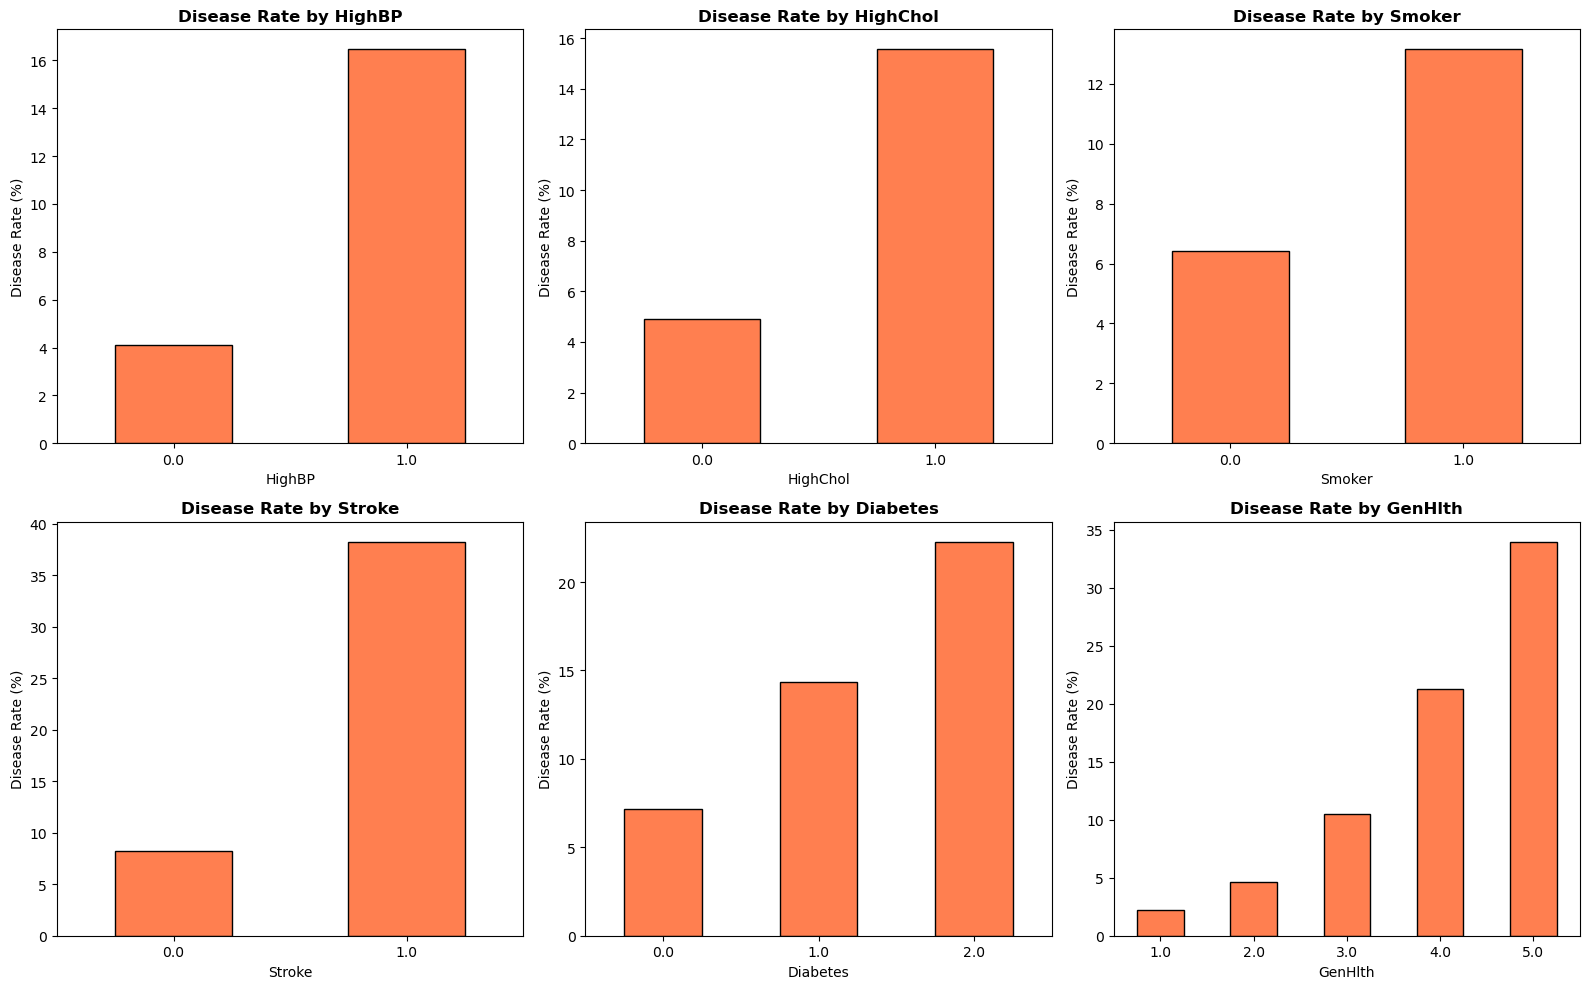

In [12]:
# disease rate by key features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

features = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'Diabetes', 'GenHlth']

i = 0
for feature in features:
    feature_disease = df.groupby(feature)['HeartDiseaseorAttack'].mean() * 100
    feature_disease.plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
    axes[i].set_title(f'Disease Rate by {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Disease Rate (%)')
    axes[i].tick_params(axis='x', rotation=0)
    i += 1

plt.tight_layout()
plt.show()

## Correlation Analysis

CORRELATION WITH HEART DISEASE (sorted by strength)

 HeartDiseaseorAttack    1.000000
GenHlth                 0.258383
Age                     0.221618
DiffWalk                0.212709
HighBP                  0.209361
Stroke                  0.203002
PhysHlth                0.181698
HighChol                0.180765
Diabetes                0.180272
Smoker                  0.114441
Sex                     0.086096
MentHlth                0.064621
BMI                     0.052904
CholCheck               0.044206
NoDocbcCost             0.031000
AnyHealthcare           0.018734
Fruits                 -0.019790
HvyAlcoholConsump      -0.028991
Veggies                -0.039167
PhysActivity           -0.087299
Education              -0.099600
Income                 -0.141011
Name: HeartDiseaseorAttack, dtype: float64


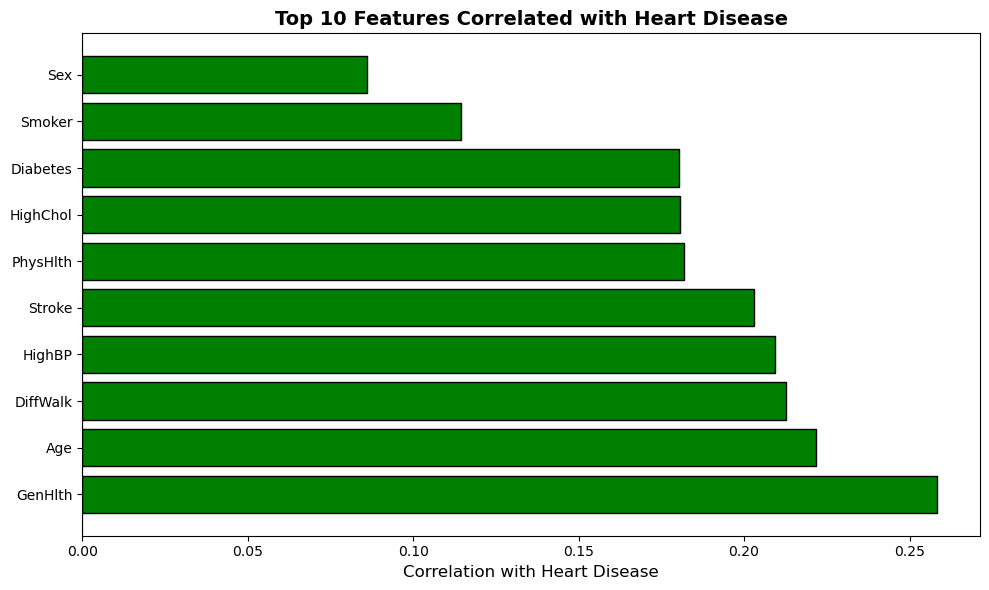

In [13]:
print("="*80)
print("CORRELATION WITH HEART DISEASE (sorted by strength)")
print("="*80)

correlations = df.corr()['HeartDiseaseorAttack'].sort_values(ascending=False)
print("\n", correlations)

top_corr = correlations[1:11]

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
plt.barh(top_corr.index, top_corr.values, color=colors, edgecolor='black')
plt.xlabel('Correlation with Heart Disease', fontsize=12)
plt.title('Top 10 Features Correlated with Heart Disease', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()

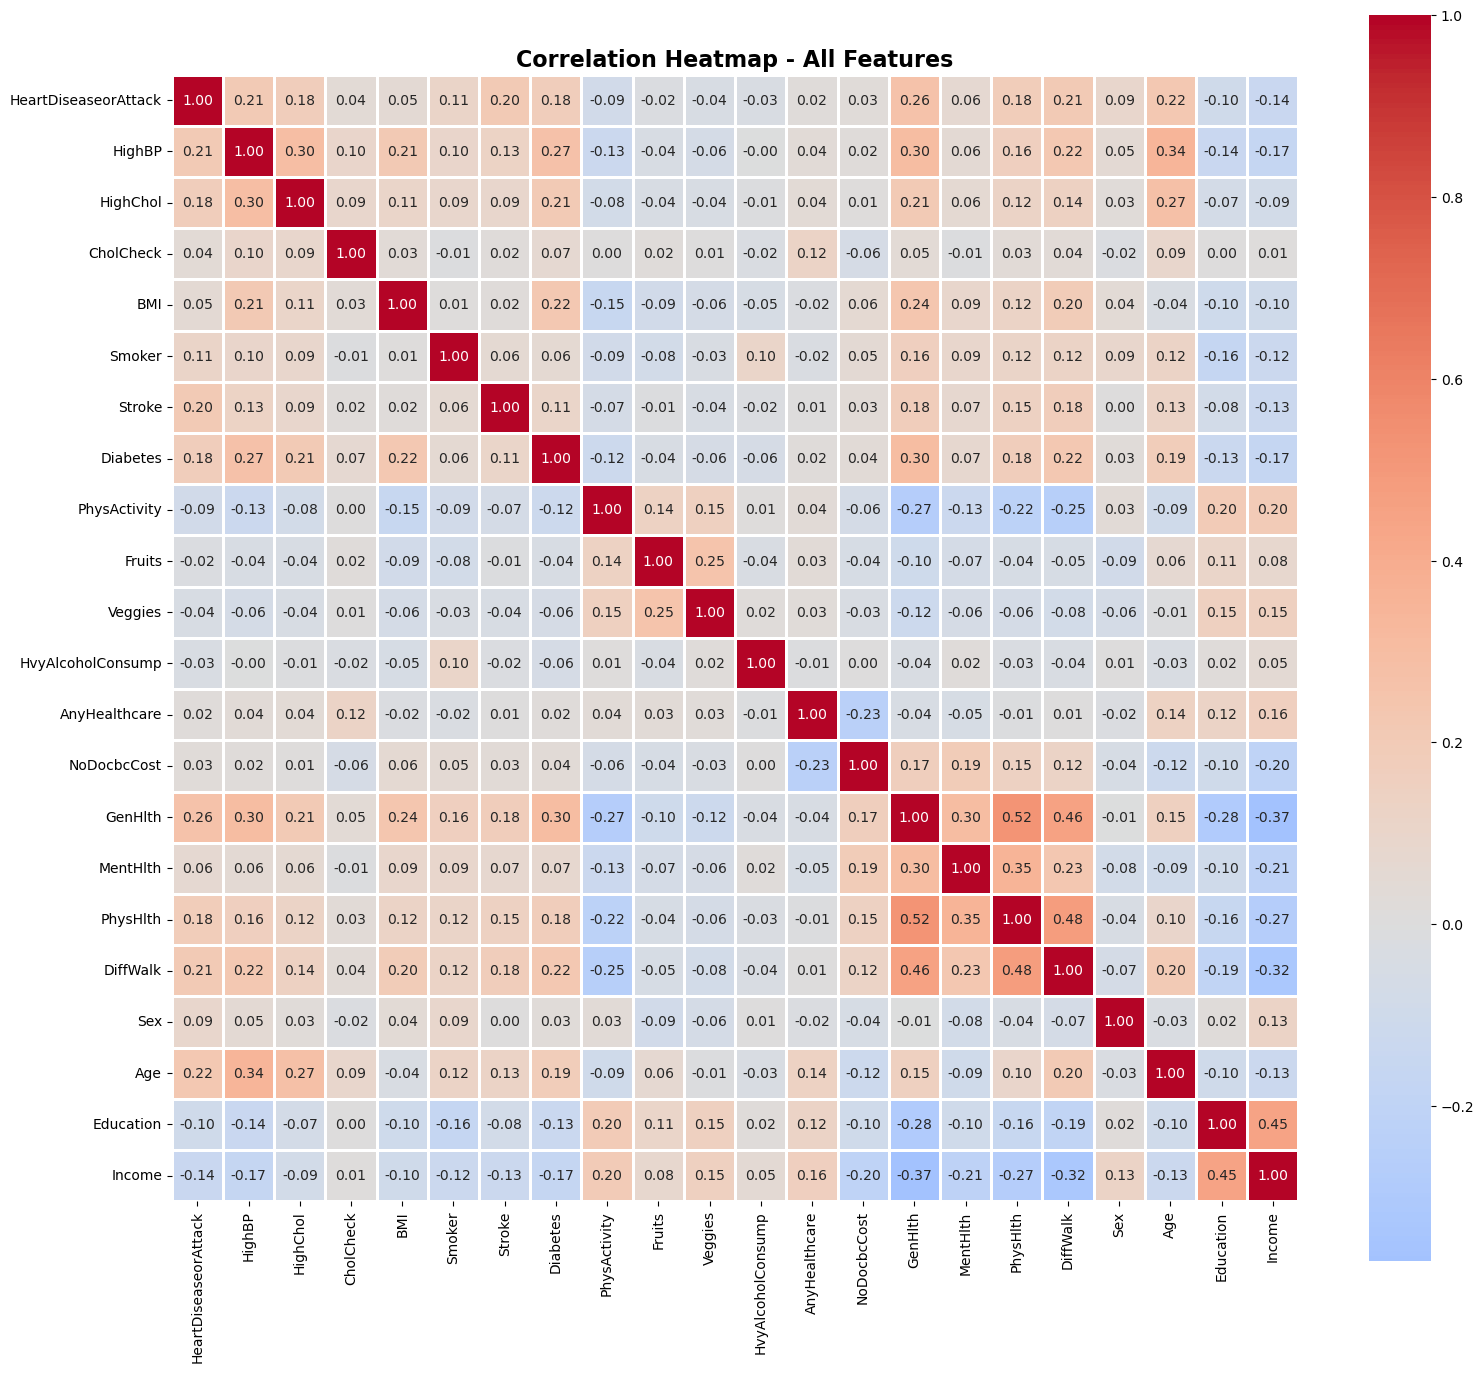

In [14]:
plt.figure(figsize=(16, 14))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap - All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Cleaning

In [15]:
print("="*80)
print(" "*30 + "DATA CLEANING")
print("="*80)

df_clean = df.copy()
initial_rows = len(df_clean)

# remove duplicates
print("\n1. Removing duplicates...")
duplicates = df_clean.duplicated().sum()
print(f"   Found: {duplicates} duplicates")

if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"   Removed: {duplicates} rows")

# remove invalid bmi
print("\n2. Removing invalid BMI values...")
print(f"  BMI range: {df_clean['BMI'].min():.1f} to {df_clean['BMI'].max():.1f}")

invalid_bmi = ((df_clean['BMI'] < 12) | (df_clean['BMI'] > 80)).sum()
print(f"  Invalid BMI (<12 or >80): {invalid_bmi}")

if invalid_bmi > 0:
    df_clean = df_clean[(df_clean['BMI'] >= 12) & (df_clean['BMI'] <= 80)]
    print(f"  Removed: {invalid_bmi} rows")

# summary
final_rows = len(df_clean)
removed = initial_rows - final_rows

print("\n" + "="*60)
print("CLEANING SUMMARY")
print("="*60)
print(f"Initial rows:    {initial_rows}")
print(f"Final rows:      {final_rows}")
print(f"Removed:         {removed}")
print(f"Retained:        {final_rows/initial_rows*100:.2f}%")

print("\nUpdated Target Distribution:")
print(df_clean['HeartDiseaseorAttack'].value_counts())

                              DATA CLEANING

1. Removing duplicates...
   Found: 23899 duplicates
   Removed: 23899 rows

2. Removing invalid BMI values...
  BMI range: 12.0 to 98.0
  Invalid BMI (<12 or >80): 279
  Removed: 279 rows

CLEANING SUMMARY
Initial rows:    253680
Final rows:      229502
Removed:         24178
Retained:        90.47%

Updated Target Distribution:
HeartDiseaseorAttack
0.0    205805
1.0     23697
Name: count, dtype: int64


## Data Preprocessing/Feature Engineering

In [16]:
print("="*80)
print(" "*25 + "DATA PREPROCESSING")
print("="*80)

print("\n1. Dropping Income and Education columns...")         # not useful
df_clean = df_clean.drop(['Income', 'Education'], axis=1)
print(f"   Dropped Income and Education")
print(f"   Remaining features: {df_clean.shape[1]}")

                         DATA PREPROCESSING

1. Dropping Income and Education columns...
   Dropped Income and Education
   Remaining features: 20


In [17]:
print("\n2. Train/Test Split (80/20)...")

X = df_clean.drop('HeartDiseaseorAttack', axis=1)
y = df_clean['HeartDiseaseorAttack']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# both sets maintain the same class proportions as the original dataset

print(f"\n   Training set: {len(X_train)} samples")
print(f"     - No disease: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"     - Has disease: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")

print(f"\n   Test set: {len(X_test)} samples")
print(f"     - No disease: {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"     - Has disease: {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")


2. Train/Test Split (80/20)...

   Training set: 183601 samples
     - No disease: 164643 (89.7%)
     - Has disease: 18958 (10.3%)

   Test set: 45901 samples
     - No disease: 41162 (89.7%)
     - Has disease: 4739 (10.3%)


In [18]:
print("\n3. Feature Scaling (StandardScaler)...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("    Features scaled")


3. Feature Scaling (StandardScaler)...


    Features scaled


## Handling Imbalance Data

In [19]:
print("\n4. Handling Class Imbalance (Undersampling)...")

# separate sick and healthy
sick_idx = (y_train.values == 1)
healthy_idx = (y_train.values == 0)

X_sick = X_train_scaled[sick_idx]
y_sick = y_train.values[sick_idx]
X_healthy = X_train_scaled[healthy_idx]
y_healthy = y_train.values[healthy_idx]

print(f"\n   Before undersampling:")
print(f"     Sick: {len(y_sick):,}")
print(f"     Healthy: {len(y_healthy):,}")
print(f"     Ratio: 1:{len(y_healthy)/len(y_sick):.1f}")

# randomly selecting healthy to match number of sick
np.random.seed(42)
sample_idx = np.random.choice(len(X_healthy), size=len(X_sick), replace=False)
X_healthy_sampled = X_healthy[sample_idx]
y_healthy_sampled = y_healthy[sample_idx]

# Combine
X_train_balanced = np.vstack([X_sick, X_healthy_sampled])
y_train_balanced = np.hstack([y_sick, y_healthy_sampled])

print(f"\n   After undersampling:")
print(f"     Sick: {(y_train_balanced==1).sum():,} (50.0%)")
print(f"     Healthy: {(y_train_balanced==0).sum():,} (50.0%)")
print(f"     Total: {len(y_train_balanced):,}")
print(f"     Perfect 50-50 balance achieved!")


4. Handling Class Imbalance (Undersampling)...

   Before undersampling:
     Sick: 18,958
     Healthy: 164,643
     Ratio: 1:8.7

   After undersampling:
     Sick: 18,958 (50.0%)
     Healthy: 18,958 (50.0%)
     Total: 37,916
     Perfect 50-50 balance achieved!


# Random Forest

## Train Model

In [20]:
print("="*80)
print(" "*25 + "RANDOM FOREST TRAINING")
print("="*80)

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

print("\nModel Configuration:")
print(f"  Algorithm: Random Forest")
print(f"  Number of trees: 200")
print(f"  Max depth: 15")
print(f"  Training samples: {len(y_train_balanced):,}")
print(f"  Features: {X_train_balanced.shape[1]}")

rf_model.fit(X_train_balanced, y_train_balanced)
print(" Training complete!")

                         RANDOM FOREST TRAINING

Model Configuration:
  Algorithm: Random Forest
  Number of trees: 200
  Max depth: 15
  Training samples: 37,916
  Features: 19
 Training complete!


## Model Evaluation

In [21]:
print("="*80)
print(" "*25 + "MODEL EVALUATION")
print("="*80)

y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*70)
print(" "*20 + "PERFORMANCE METRICS")
print("="*70)
print(f"Recall (Sensitivity):     {recall*100:.2f}%  (PRIMARY METRIC)")
print(f"Precision:                {precision*100:.2f}%")
print(f"Accuracy:                 {accuracy*100:.2f}%")
print(f"F1-Score:                 {f1:.4f}")
print(f"ROC-AUC:                  {roc_auc:.4f}")
print("="*70)

                         MODEL EVALUATION

                    PERFORMANCE METRICS
Recall (Sensitivity):     81.68%  (PRIMARY METRIC)
Precision:                24.32%
Accuracy:                 71.87%
F1-Score:                 0.3749
ROC-AUC:                  0.8345


In [22]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"  True Negatives (Correct Healthy):    {tn:,}")
print(f"  False Positives (False Alarms):      {fp:,}")
print(f"  False Negatives (Missed Sick):       {fn:,}")
print(f"  True Positives (Caught Sick):        {tp:,}")

total_sick = fn + tp
print(f"\nMedical Interpretation:")
print(f"  Total sick people:    {total_sick:,}")
print(f"  Caught:               {tp} ({recall*100:.1f}%)")
print(f"  Missed:               {fn} ({fn/total_sick*100:.1f}%)")
print(f"  False alarm rate:     {fp/(tn+fp)*100:.2f}%")


Confusion Matrix:
  True Negatives (Correct Healthy):    29,119
  False Positives (False Alarms):      12,043
  False Negatives (Missed Sick):       868
  True Positives (Caught Sick):        3,871

Medical Interpretation:
  Total sick people:    4,739
  Caught:               3871 (81.7%)
  Missed:               868 (18.3%)
  False alarm rate:     29.26%


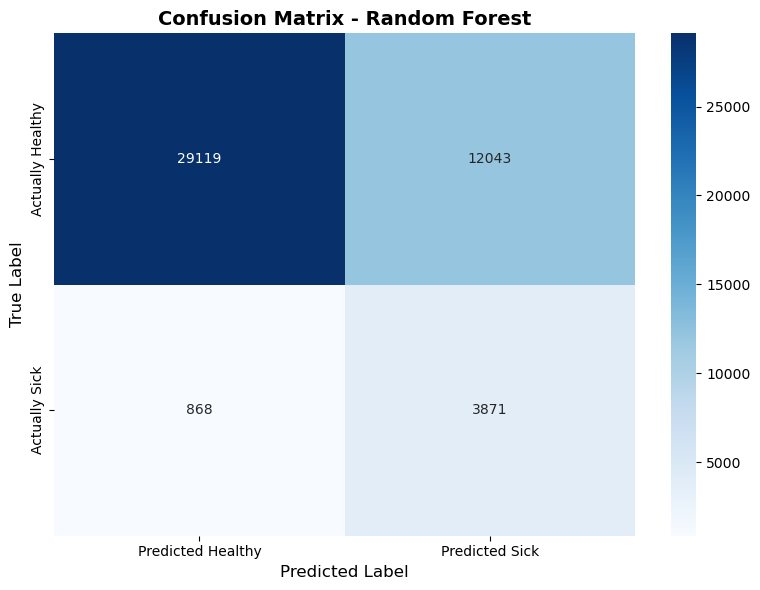

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
           xticklabels=['Predicted Healthy', 'Predicted Sick'],
           yticklabels=['Actually Healthy', 'Actually Sick'])
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

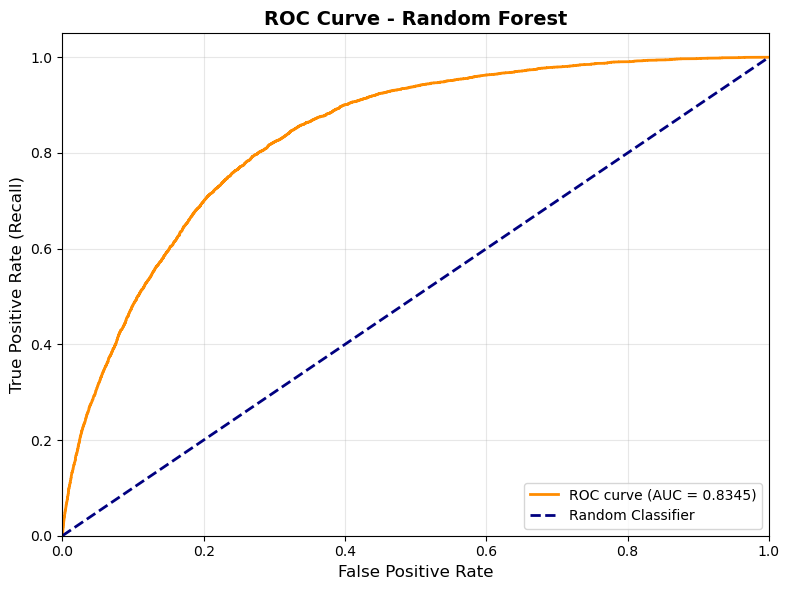

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Importance

In [25]:
print("="*80)
print(" "*25 + "FEATURE IMPORTANCE")
print("="*80)

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print("-" * 50)
for i in range(10):
    feature = feature_importance.iloc[i]['Feature']
    importance = feature_importance.iloc[i]['Importance']
    print(f"{i+1:2d}. {feature:20s}  {importance*100:5.2f}%")

print("-" * 50)

                         FEATURE IMPORTANCE

Top 10 Most Important Features:
--------------------------------------------------
 1. Age                   23.02%
 2. GenHlth               14.42%
 3. HighBP                12.63%
 4. HighChol               7.67%
 5. PhysHlth               6.39%
 6. BMI                    6.33%
 7. DiffWalk               5.72%
 8. Sex                    4.64%
 9. Stroke                 4.63%
10. Diabetes               3.64%
--------------------------------------------------


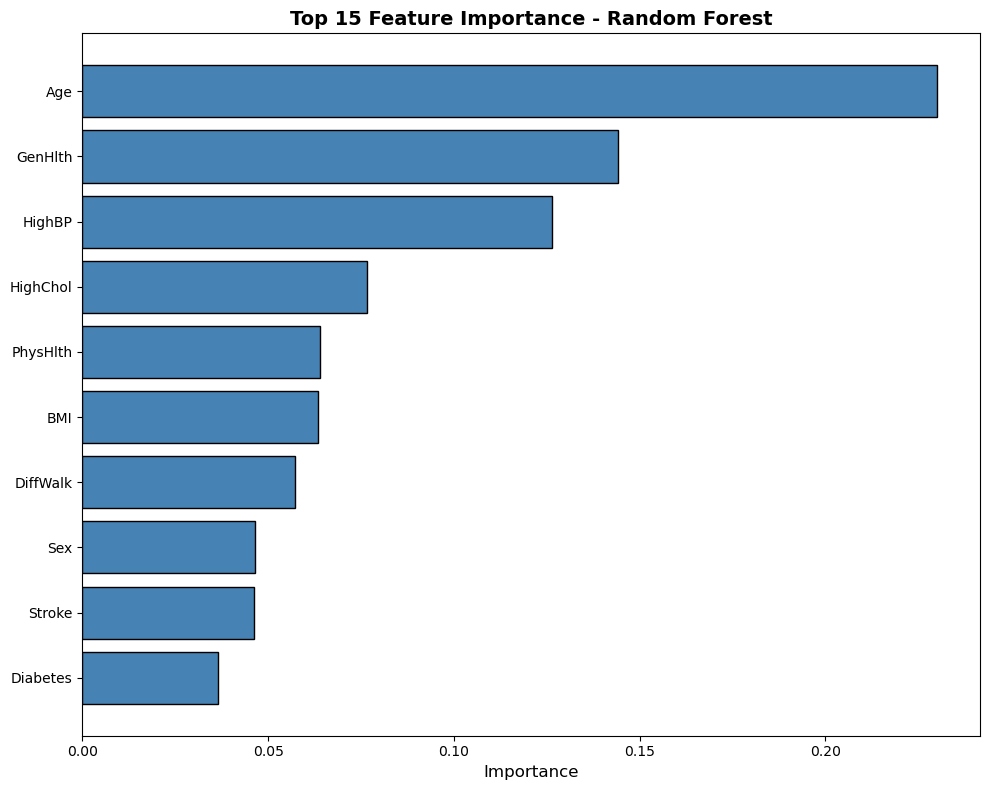

In [26]:
plt.figure(figsize=(10, 8))
top10 = feature_importance.head(10)

plt.barh(range(len(top10)), top10['Importance'].values, color='steelblue', edgecolor='black')
plt.yticks(range(len(top10)), top10['Feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Logistic Regression

## Train Model

In [27]:
print("="*80)
print(" "*20 + "LOGISTIC REGRESSION TRAINING")
print("="*80)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

print("\nModel Configuration:")
print(f"  Algorithm: Logistic Regression")
print(f"  Max iterations: 1000")
print(f"  Training samples: {len(y_train_balanced):,}")
print(f"  Features: {X_train_balanced.shape[1]}")

lr_model.fit(X_train_balanced, y_train_balanced)
print(" Training complete!")

                    LOGISTIC REGRESSION TRAINING

Model Configuration:
  Algorithm: Logistic Regression
  Max iterations: 1000
  Training samples: 37,916
  Features: 19
 Training complete!


## Model Evaluation

In [28]:
print("="*80)
print(" "*25 + "MODEL EVALUATION")
print("="*80)

lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_recall = recall_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_pred_proba)

print("\n" + "="*70)
print(" "*20 + "PERFORMANCE METRICS")
print("="*70)
print(f"Recall (Sensitivity):     {lr_recall*100:6.2f}%  PRIMARY METRIC")
print(f"Precision:                {lr_precision*100:6.2f}%")
print(f"Accuracy:                 {lr_accuracy*100:6.2f}%")
print(f"F1-Score:                 {lr_f1:6.4f}")
print(f"ROC-AUC:                  {lr_roc_auc:6.4f}")
print("="*70)

                         MODEL EVALUATION

                    PERFORMANCE METRICS
Recall (Sensitivity):      78.81%  PRIMARY METRIC
Precision:                 25.65%
Accuracy:                  74.22%
F1-Score:                 0.3870
ROC-AUC:                  0.8357



Confusion Matrix:
  True Negatives (Correct Healthy):    30,335
  False Positives (False Alarms):      10,827
  False Negatives (Missed Sick):       1,004
  True Positives (Caught Sick):        3,735

Medical Interpretation:
  Total sick people: 4,739
  Caught: 3,735 (78.8%)
  Missed: 1,004 (21.2%)
  False alarm rate: 26.30%


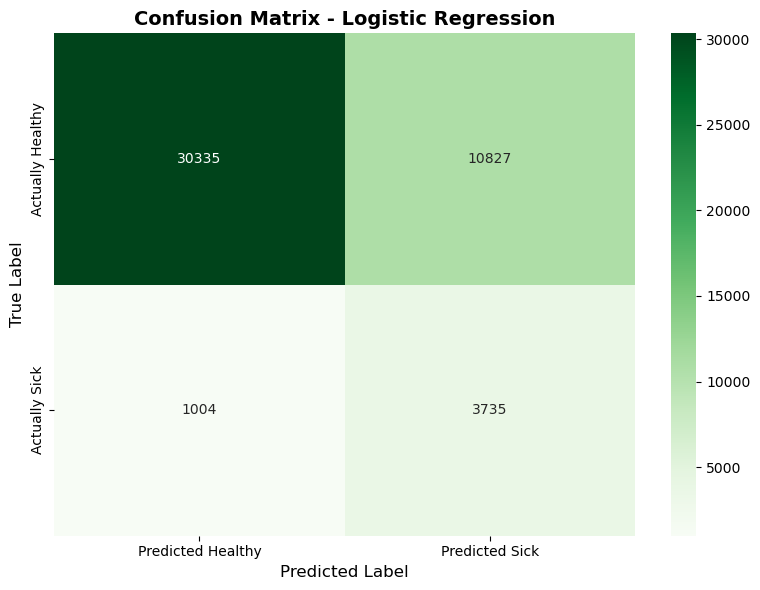

In [29]:
lr_cm = confusion_matrix(y_test, lr_pred)
lr_tn, lr_fp, lr_fn, lr_tp = lr_cm.ravel()

print("\nConfusion Matrix:")
print(f"  True Negatives (Correct Healthy):    {lr_tn:,}")
print(f"  False Positives (False Alarms):      {lr_fp:,}")
print(f"  False Negatives (Missed Sick):       {lr_fn:,}")
print(f"  True Positives (Caught Sick):        {lr_tp:,}")

lr_total_sick = lr_fn + lr_tp
print(f"\nMedical Interpretation:")
print(f"  Total sick people: {lr_total_sick:,}")
print(f"  Caught: {lr_tp:,} ({lr_recall*100:.1f}%)")
print(f"  Missed: {lr_fn:,} ({lr_fn/lr_total_sick*100:.1f}%)")
print(f"  False alarm rate: {lr_fp/(lr_tn+lr_fp)*100:.2f}%")

plt.figure(figsize=(8, 6))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Greens', cbar=True,
           xticklabels=['Predicted Healthy', 'Predicted Sick'],
           yticklabels=['Actually Healthy', 'Actually Sick'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

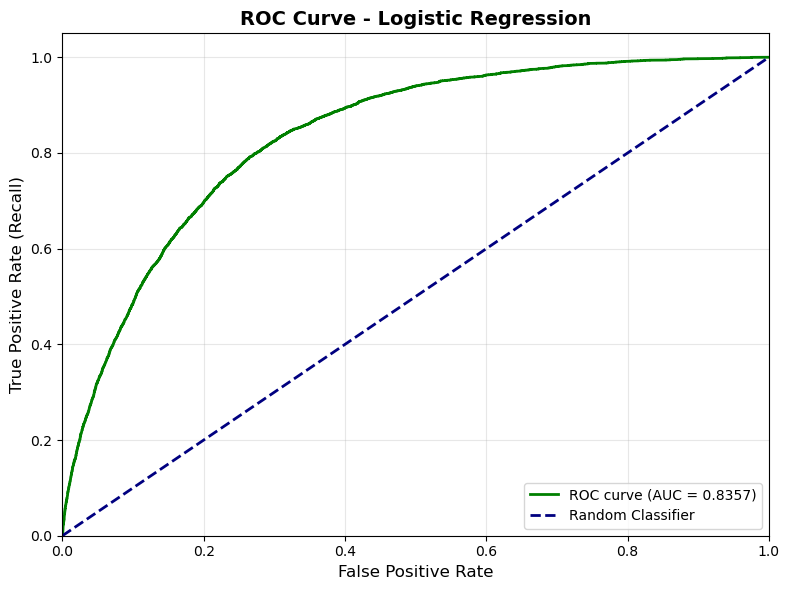

In [30]:
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, lr_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, color='green', lw=2, label=f'ROC curve (AUC = {lr_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# MODEL COMPARISON: Random Forest vs Logistic Regression

In [31]:
print("="*80)
print(" "*25 + "MODEL COMPARISON")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy (%)': [accuracy * 100, lr_accuracy * 100],
    'Precision (%)': [precision * 100, lr_precision * 100],
    'Recall (%)': [recall * 100, lr_recall * 100],
    'F1-Score': [f1, lr_f1],
    'ROC-AUC': [roc_auc, lr_roc_auc]
})

print("\nPerformance Comparison Table:")
print("="*90)
print(comparison_df.to_string())
print("="*90)

comparison_df

                         MODEL COMPARISON

Performance Comparison Table:
                 Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score   ROC-AUC
0        Random Forest     71.872073      24.324494   81.683900  0.374861  0.834543
1  Logistic Regression     74.224962      25.648949   78.814096  0.387027  0.835722


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score,ROC-AUC
0,Random Forest,71.872073,24.324494,81.683900,0.374861,0.834543
1,Logistic Regression,74.224962,25.648949,78.814096,0.387027,0.835722


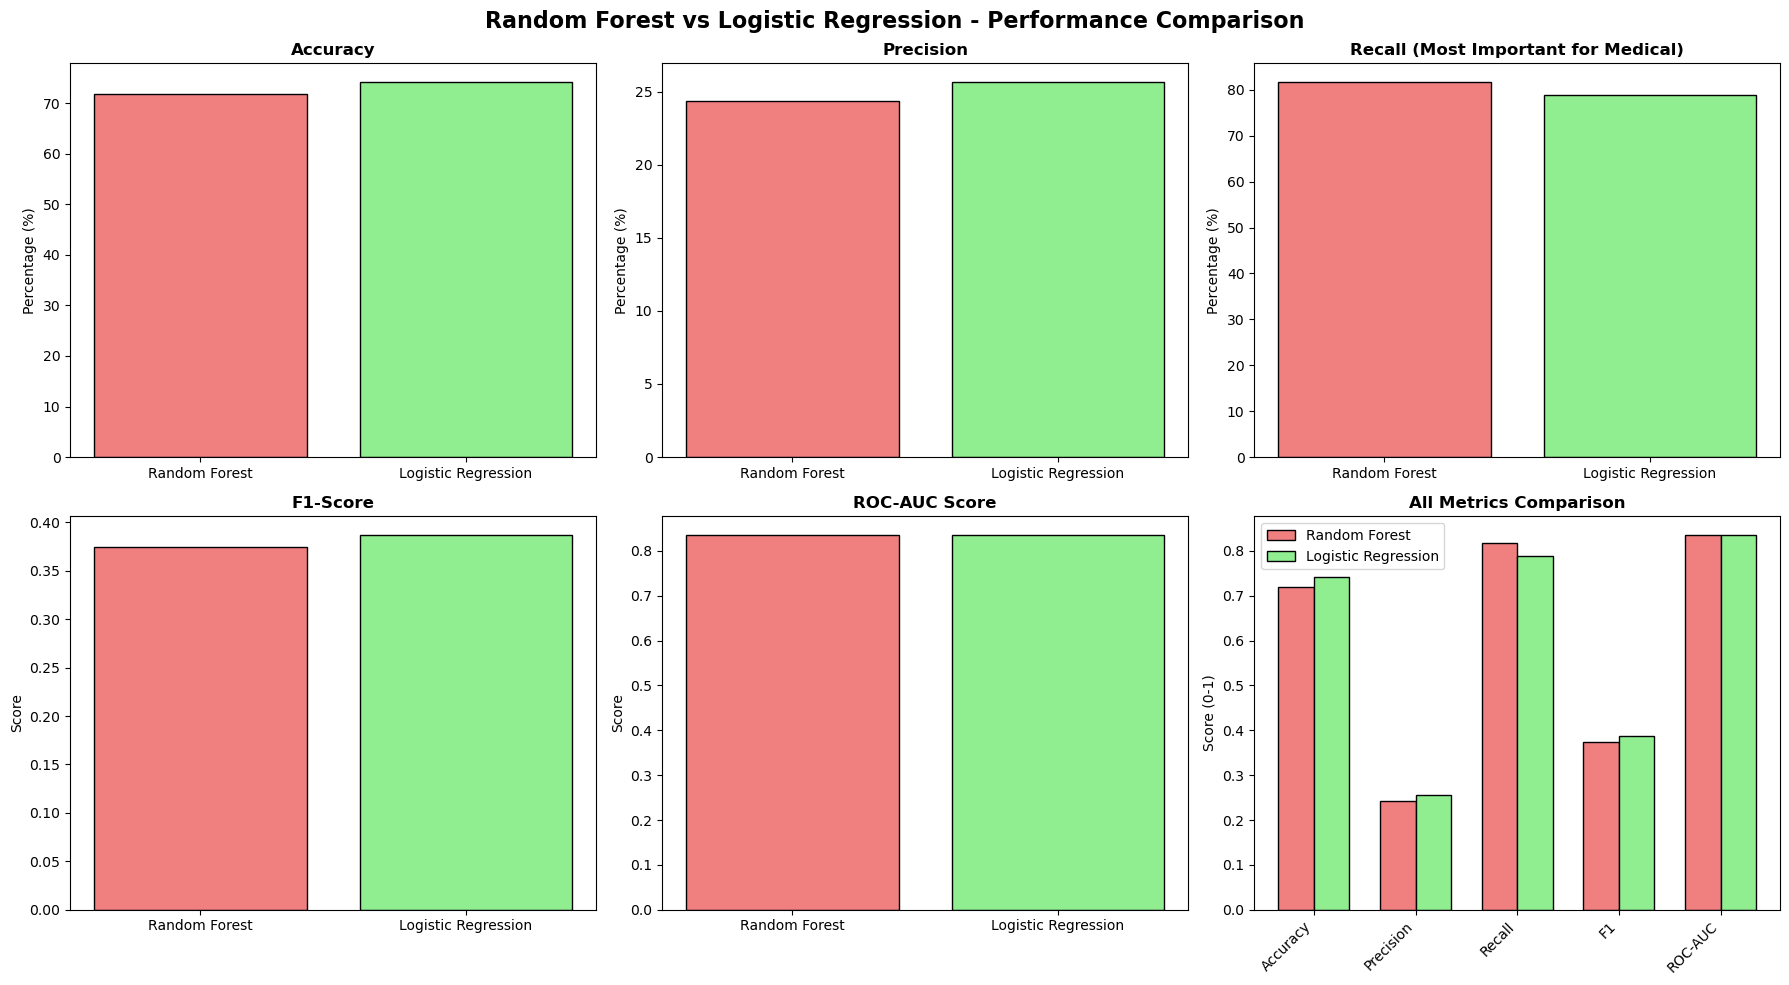

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Random Forest vs Logistic Regression - Performance Comparison', 
             fontsize=16, fontweight='bold')

models = comparison_df['Model'].values
colors = ['lightcoral', 'lightgreen']

# accuracy
axes[0, 0].bar(models, comparison_df['Accuracy (%)'], color=colors, edgecolor='black')
axes[0, 0].set_title('Accuracy', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Percentage (%)')

# precision
axes[0, 1].bar(models, comparison_df['Precision (%)'], color=colors, edgecolor='black')
axes[0, 1].set_title('Precision', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Percentage (%)')

# recall
axes[0, 2].bar(models, comparison_df['Recall (%)'], color=colors, edgecolor='black')
axes[0, 2].set_title('Recall (Most Important for Medical)', fontweight='bold', fontsize=12)
axes[0, 2].set_ylabel('Percentage (%)')

# f1
axes[1, 0].bar(models, comparison_df['F1-Score'], color=colors, edgecolor='black')
axes[1, 0].set_title('F1-Score', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Score')

# roc
axes[1, 1].bar(models, comparison_df['ROC-AUC'], color=colors, edgecolor='black')
axes[1, 1].set_title('ROC-AUC Score', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Score')

# metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
rf_scores = [
    comparison_df.loc[0, 'Accuracy (%)'] / 100,
    comparison_df.loc[0, 'Precision (%)'] / 100,
    comparison_df.loc[0, 'Recall (%)'] / 100,
    comparison_df.loc[0, 'F1-Score'],
    comparison_df.loc[0, 'ROC-AUC']
]
lr_scores = [
    comparison_df.loc[1, 'Accuracy (%)'] / 100,
    comparison_df.loc[1, 'Precision (%)'] / 100,
    comparison_df.loc[1, 'Recall (%)'] / 100,
    comparison_df.loc[1, 'F1-Score'],
    comparison_df.loc[1, 'ROC-AUC']
]

x = np.arange(len(metrics))
width = 0.35

axes[1, 2].bar(x - width/2, rf_scores, width, label='Random Forest', 
               color='lightcoral', edgecolor='black')
axes[1, 2].bar(x + width/2, lr_scores, width, label='Logistic Regression', 
               color='lightgreen', edgecolor='black')
axes[1, 2].set_title('All Metrics Comparison', fontweight='bold', fontsize=12)
axes[1, 2].set_ylabel('Score (0-1)')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(metrics, rotation=45, ha='right')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

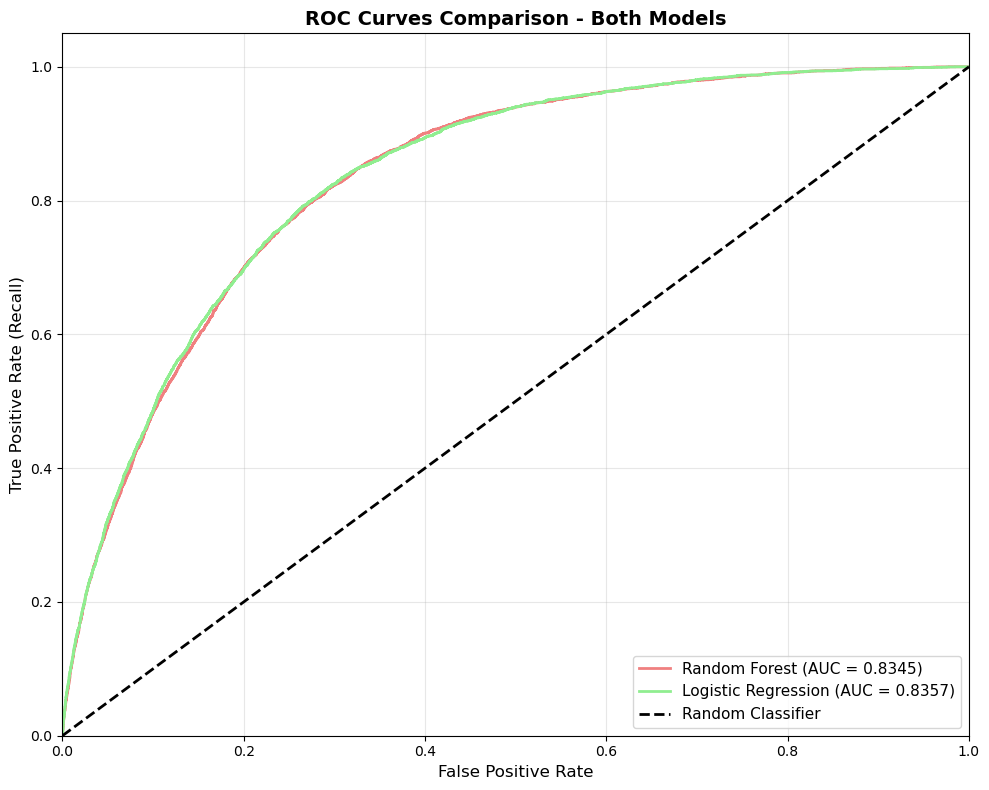

In [33]:
# roc comparison
plt.figure(figsize=(10, 8))

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr_rf, tpr_rf, color='lightcoral', lw=2, 
         label=f'Random Forest (AUC = {roc_auc:.4f})')

plt.plot(lr_fpr, lr_tpr, color='lightgreen', lw=2, 
         label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves Comparison - Both Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

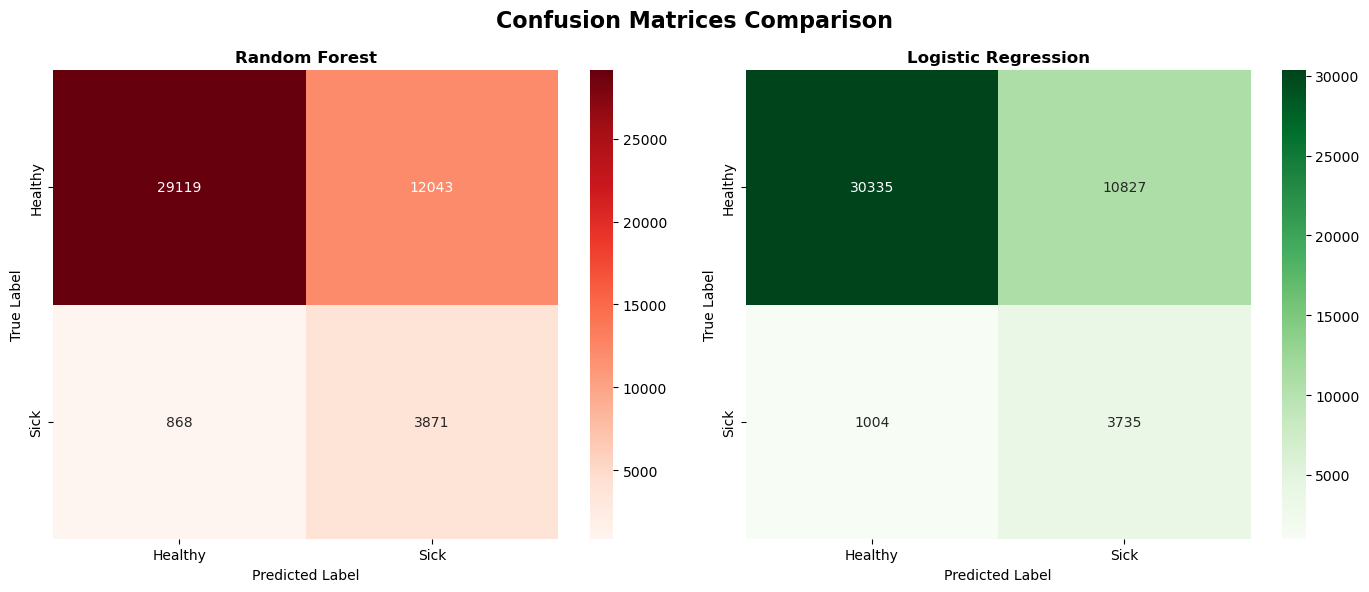

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrices Comparison', fontsize=16, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
           xticklabels=['Healthy', 'Sick'],
           yticklabels=['Healthy', 'Sick'])
axes[0].set_title('Random Forest', fontweight='bold', fontsize=12)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
           xticklabels=['Healthy', 'Sick'],
           yticklabels=['Healthy', 'Sick'])
axes[1].set_title('Logistic Regression', fontweight='bold', fontsize=12)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Checking robustness

In [35]:
print("="*80)
print(" "*15 + "ROBUSTNESS TESTING ON SYNTHETIC PATIENTS")
print("="*80)


print("\n1. CREATING SYNTHETIC PATIENTS FOR ROBUSTNESS ANALYSIS:")
print("-" * 70)

# Create 40 synthetic patients (10 simple, 10 complex, 10 paradox, 10 extreme)

synthetic_patients = pd.DataFrame({
    'S1': [0,0,1,22,0,0,0,1,1,1,0,1,0,1,0,0,0,1,2],
    'S2': [1,1,1,35,1,0,1,0,0,0,0,1,0,4,10,15,1,1,11],
    'S3': [1,1,1,30,1,1,2,0,0,0,0,1,1,5,20,25,1,1,12],
    'S4': [0,0,1,24,0,0,0,1,1,1,0,1,0,1,0,0,0,0,3],
    'S5': [1,1,1,40,1,1,2,0,0,0,0,0,1,5,30,30,1,1,13],
    'S6': [0,0,1,27,0,0,0,1,1,0,0,1,0,2,2,1,0,1,7],
    'S7': [0,1,1,38,1,0,1,0,0,0,0,1,0,3,5,3,0,1,4],
    'S8': [0,0,1,24,0,0,0,1,1,1,0,1,0,1,0,0,0,0,10],
    'S9': [1,1,1,32,0,0,2,0,0,0,0,1,0,4,15,20,1,0,9],
    'S10': [1,0,1,26,0,0,0,1,1,1,0,1,0,2,0,0,0,1,5],

    'C1': [0,0,1,23,0,0,0,1,1,1,0,1,0,1,0,0,0,1,12],
    'C2': [1,1,1,42,1,0,2,0,0,0,0,1,0,4,15,20,1,1,4],
    'C3': [1,0,1,28,0,0,0,1,1,1,0,1,0,2,0,0,0,0,9],
    'C4': [0,0,1,24,0,1,0,1,1,1,0,1,0,2,0,0,0,1,8],
    'C5': [0,0,1,29,0,0,1,0,0,0,0,1,0,3,5,5,0,1,8],
    'C6': [0,0,0,22,0,0,0,1,0,0,0,0,1,2,10,0,0,0,10],
    'C7': [0,0,1,32,1,0,0,0,0,0,1,1,0,1,0,0,0,1,7],
    'C8': [0,0,1,22,0,0,2,1,1,1,0,1,0,2,0,0,0,0,6],
    'C9': [0,0,1,25,0,0,0,0,1,1,0,1,0,3,0,20,1,0,8],
    'C10': [0,0,1,24,0,0,0,0,0,0,0,1,0,3,30,0,0,1,7],

    'P1': [0,0,1,21,0,0,0,1,1,1,0,1,0,1,0,0,0,0,13],
    'P2': [0,0,1,23,0,1,0,1,1,1,0,1,0,2,0,0,0,1,3],
    'P3': [0,0,1,24,0,0,0,1,1,1,0,1,0,5,0,0,0,1,9],
    'P4': [0,0,1,50,0,0,0,0,0,0,0,1,0,3,0,0,0,1,2],
    'P5': [0,0,1,27,1,0,2,1,1,1,0,1,0,1,0,0,0,1,11],
    'P6': [0,0,1,24,0,0,0,0,1,1,0,1,0,1,30,30,1,0,8],
    'P7': [1,1,1,38,1,0,2,0,0,0,1,0,1,4,20,25,1,1,5],
    'P8': [0,0,0,23,0,0,0,1,0,0,0,0,1,2,15,0,0,0,9],
    'P9': [0,0,1,24,0,1,2,1,1,1,0,1,0,2,0,5,0,0,12],
    'P10': [0,0,1,15,0,0,0,1,1,1,0,1,0,3,20,10,1,0,7],

    'E1': [1,1,1,35,1,1,2,0,0,0,1,0,1,1,0,0,0,1,12],
    'E2': [0,0,1,22,0,1,2,1,1,1,0,1,0,1,0,0,0,1,1],
    'E3': [1,1,0,18,1,0,1,1,0,1,1,0,1,3,15,15,0,0,6],
    'E4': [0,0,1,60,0,0,0,1,1,1,0,1,0,2,0,0,0,1,4],
    'E5': [0,0,1,22,0,0,0,1,1,1,0,1,0,1,0,0,0,1,13],
    'E6': [1,1,1,16,1,1,2,0,0,0,1,0,1,5,30,30,1,1,2],
    'E7': [0,0,1,45,1,0,0,0,0,0,1,1,0,1,0,0,0,1,10],
    'E8': [1,1,1,32,1,1,2,0,0,0,0,1,0,2,0,0,0,1,3],
    'E9': [0,1,0,29,0,1,1,1,0,1,0,1,0,3,10,20,0,0,7],
    'E10': [0,0,1,18,0,1,2,1,1,1,0,1,0,2,30,0,1,0,13]

}, index=X.columns).T

print(f"\nCreated 40 synthetic patients:")
print(f"  • Simple: 10 patients (clear healthy/sick cases)")
print(f"  • Complex: 10 patients (edge cases)")
print(f"  • Paradox: 10 patients (conflicting indicators)")
print(f"  • Extreme: 10 patients (unusual combinations)")

               ROBUSTNESS TESTING ON SYNTHETIC PATIENTS

1. CREATING SYNTHETIC PATIENTS FOR ROBUSTNESS ANALYSIS:
----------------------------------------------------------------------

Created 40 synthetic patients:
  • Simple: 10 patients (clear healthy/sick cases)
  • Complex: 10 patients (edge cases)
  • Paradox: 10 patients (conflicting indicators)
  • Extreme: 10 patients (unusual combinations)


In [36]:
print("\n\n2. PREPROCESSING SYNTHETIC PATIENTS:")
print("-" * 70)

X_synthetic_scaled = scaler.transform(synthetic_patients)
print(" Scaled synthetic patients using training scaler")

print("\n\n3. MAKING PREDICTIONS:")
print("-" * 70)

rf_synth_pred = rf_model.predict(X_synthetic_scaled)
rf_synth_proba = rf_model.predict_proba(X_synthetic_scaled)[:, 1]

lr_synth_pred = lr_model.predict(X_synthetic_scaled)
lr_synth_proba = lr_model.predict_proba(X_synthetic_scaled)[:, 1]

print(" Random Forest predictions complete")
print(" Logistic Regression predictions complete")




2. PREPROCESSING SYNTHETIC PATIENTS:
----------------------------------------------------------------------
 Scaled synthetic patients using training scaler


3. MAKING PREDICTIONS:
----------------------------------------------------------------------
 Random Forest predictions complete
 Logistic Regression predictions complete


In [37]:
print("\n\n4. ROBUSTNESS ANALYSIS BY PATIENT CATEGORY:")
print("=" * 80)

categories = ['Simple']*10 + ['Complex']*10 + ['Paradox']*10 + ['Extreme']*10
patient_ids = synthetic_patients.index.tolist()

results_df = pd.DataFrame({
    'Patient_ID': patient_ids,
    'Category': categories,
    'RF_Prediction': ['HIGH RISK' if p==1 else 'Low Risk' for p in rf_synth_pred],
    'RF_Probability': rf_synth_proba * 100,
    'LR_Prediction': ['HIGH RISK' if p==1 else 'Low Risk' for p in lr_synth_pred],
    'LR_Probability': lr_synth_proba * 100
})

results_df['Agreement'] = results_df['RF_Prediction'] == results_df['LR_Prediction']

categories_list = ['Simple', 'Complex', 'Paradox', 'Extreme']
for category in categories_list:
    cat_data = results_df[results_df['Category'] == category]

    print(f"\n{category.upper()} CASES:")
    print("-" * 80)

    rf_high_risk = (cat_data['RF_Prediction'] == 'HIGH RISK').sum()
    lr_high_risk = (cat_data['LR_Prediction'] == 'HIGH RISK').sum()
    agreement = cat_data['Agreement'].sum()

    print(f"  Random Forest:        {rf_high_risk}/10 predicted HIGH RISK")
    print(f"  Logistic Regression:  {lr_high_risk}/10 predicted HIGH RISK")
    print(f"  Agreement:            {agreement}/10 predictions match ({agreement*10}%)")

    disagreements = cat_data[~cat_data['Agreement']]
    if len(disagreements) > 0:
        print(f"\n  Disagreements:")
        for _, row in disagreements.iterrows():
            print(f"    {row['Patient_ID']}: RF={row['RF_Prediction']}, LR={row['LR_Prediction']}")


print("\n\n5. OVERALL ROBUSTNESS COMPARISON:")
print("=" * 80)

rf_total_high = (results_df['RF_Prediction'] == 'HIGH RISK').sum()
lr_total_high = (results_df['LR_Prediction'] == 'HIGH RISK').sum()
total_agreement = results_df['Agreement'].sum()

print(f"\nTotal Predictions (out of 40 patients):")
print(f"  Random Forest:        {rf_total_high} HIGH RISK, {40-rf_total_high} Low Risk")
print(f"  Logistic Regression:  {lr_total_high} HIGH RISK, {40-lr_total_high} Low Risk")
print(f"  Model Agreement:      {total_agreement}/40 ({total_agreement/40*100:.1f}%)")

disagreements_total = results_df[~results_df['Agreement']]
print(f"\n  Total Disagreements: {len(disagreements_total)}/40 patients")

if len(disagreements_total) > 0:
    rf_more_cautious = ((results_df['RF_Prediction'] == 'HIGH RISK') & 
                        (results_df['LR_Prediction'] == 'Low Risk')).sum()
    lr_more_cautious = ((results_df['RF_Prediction'] == 'Low Risk') & 
                        (results_df['LR_Prediction'] == 'HIGH RISK')).sum()

    print(f"     RF more cautious: {rf_more_cautious} cases")
    print(f"     LR more cautious: {lr_more_cautious} cases")


print("\n\n6. ROBUSTNESS METRICS:")
print("=" * 80)

print(f"\nAverage Probability of Heart Disease:")
print(f"  Random Forest:        {rf_synth_proba.mean()*100:.2f}%")
print(f"  Logistic Regression:  {lr_synth_proba.mean()*100:.2f}%")

print(f"\nProbability Standard Deviation:")
print(f"  Random Forest:        {rf_synth_proba.std()*100:.2f}%")
print(f"  Logistic Regression:  {lr_synth_proba.std()*100:.2f}%")

rf_high_conf = ((rf_synth_proba > 0.7) | (rf_synth_proba < 0.3)).sum()
lr_high_conf = ((lr_synth_proba > 0.7) | (lr_synth_proba < 0.3)).sum()

print(f"\nHigh Confidence Predictions (>70% or <30%):")
print(f"  Random Forest:        {rf_high_conf}/40 ({rf_high_conf/40*100:.1f}%)")
print(f"  Logistic Regression:  {lr_high_conf}/40 ({lr_high_conf/40*100:.1f}%)")

print("\n\n7. ROBUSTNESS SUMMARY:")
print("=" * 80)

if rf_total_high > lr_total_high:
    more_cautious = "Random Forest"
    cautious_diff = rf_total_high - lr_total_high
elif lr_total_high > rf_total_high:
    more_cautious = "Logistic Regression"
    cautious_diff = lr_total_high - rf_total_high
else:
    more_cautious = "Both models equally"
    cautious_diff = 0

print(f"\n KEY ROBUSTNESS FINDINGS:")
print(f"\n1. More Cautious Model:")
print(f"    {more_cautious} is MORE CAUTIOUS")
if cautious_diff > 0:
    print(f"    Predicts {cautious_diff} more HIGH RISK cases")

print(f"\n2. Model Agreement (Robustness Indicator):")
print(f"    Models agree on {total_agreement}/40 patients ({total_agreement/40*100:.1f}%)")
if total_agreement/40 >= 0.75:
    print(f"    HIGH robustness - consistent predictions")
elif total_agreement/40 >= 0.50:
    print(f"    MODERATE robustness - some variation")
else:
    print(f"    LOW robustness - significant variation")

print(f"\n3. Robustness Across Different Case Types:")
for cat in categories_list:
    cat_agree = results_df[results_df['Category']==cat]['Agreement'].sum()
    print(f"    {cat}: {cat_agree}/10 agreement ")
    if cat_agree >= 8:
        print("(High robustness)")
    elif cat_agree >= 5:
        print("(Moderate robustness)")
    else:
        print("(Low robustness)")

print(f"\n4. Recommendation for Medical Screening:")
if rf_total_high >= lr_total_high:
    print(f"   - Random Forest is MORE SENSITIVE (catches more potential cases)")
    print(f"   - Better for medical screening where missing cases is costly")
    print(f"   - Recommended Model: Random Forest ")
else:
    print(f"   - Logistic Regression is MORE SENSITIVE (catches more potential cases)")
    print(f"   - Better for medical screening where missing cases is costly")
    print(f"   - Recommended Model: Logistic Regression ")

print("\n" + "="*80)
print(" "*20 + "ROBUSTNESS TESTING COMPLETE!")
print("="*80)



4. ROBUSTNESS ANALYSIS BY PATIENT CATEGORY:

SIMPLE CASES:
--------------------------------------------------------------------------------
  Random Forest:        4/10 predicted HIGH RISK
  Logistic Regression:  4/10 predicted HIGH RISK
  Agreement:            10/10 predictions match (100%)

COMPLEX CASES:
--------------------------------------------------------------------------------
  Random Forest:        2/10 predicted HIGH RISK
  Logistic Regression:  1/10 predicted HIGH RISK
  Agreement:            9/10 predictions match (90%)

  Disagreements:
    C4: RF=HIGH RISK, LR=Low Risk

PARADOX CASES:
--------------------------------------------------------------------------------
  Random Forest:        2/10 predicted HIGH RISK
  Logistic Regression:  3/10 predicted HIGH RISK
  Agreement:            9/10 predictions match (90%)

  Disagreements:
    P3: RF=Low Risk, LR=HIGH RISK

EXTREME CASES:
--------------------------------------------------------------------------------
  Random

In [38]:
print("="*80)
print(" "*25 + "DISCUSSION OF RESULTS")
print("="*80)

print("\n1. PERFORMANCE COMPARISON:")
print("-" * 70)

print("\n   Metric          Random Forest    Logistic Regression    Winner")
print("   " + "-"*70)
print(f"   Accuracy        {accuracy*100:6.2f}%          {lr_accuracy*100:6.2f}%              {'RF' if accuracy > lr_accuracy else 'LR'}")
print(f"   Precision       {precision*100:6.2f}%          {lr_precision*100:6.2f}%              {'RF' if precision > lr_precision else 'LR'}")
print(f"   Recall*         {recall*100:6.2f}%          {lr_recall*100:6.2f}%              {'RF' if recall > lr_recall else 'LR'}")
print(f"   F1-Score        {f1:.4f}           {lr_f1:.4f}              {'RF' if f1 > lr_f1 else 'LR'}")
print(f"   ROC-AUC         {roc_auc:.4f}           {lr_roc_auc:.4f}              {'RF' if roc_auc > lr_roc_auc else 'LR'}")
print("   " + "-"*70)
print("   * Most important for medical screening")

recall_diff = abs(recall - lr_recall) * 100
if recall > lr_recall:
    print(f"\n   - Random Forest catches {recall_diff:.2f}% MORE sick patients!")
else:
    print(f"\n   - Logistic Regression catches {recall_diff:.2f}% MORE sick patients!")


print("\n\n2. TRAINING & COMPUTATIONAL EFFICIENCY:")
print("-" * 70)

print("\n   Training Time:")
print("     Random Forest:        Moderate (builds 200 trees)")
print("     Logistic Regression:  Fast (simple optimization)")
print("     - Winner: Logistic Regression")

print("\n   Prediction Speed:")
print("     Random Forest:        Fast (parallel evaluation)")
print("     Logistic Regression:  Very Fast (simple calculation)")
print("     - Winner: Tie (both fast enough for real-time)")

print("\n   Memory Usage:")
print("     Random Forest:        Moderate (stores 200 trees)")
print("     Logistic Regression:  Low (only coefficients)")
print("     - Winner: Logistic Regression")


print("\n\n3. MODEL ROBUSTNESS:")
print("-" * 70)

print("\n   Overfitting Risk:")
print("     Random Forest:        Very Low (ensemble averaging reduces overfitting)")
print("     Logistic Regression:  Low (but can underfit)")
print("     - Winner: Random Forest (better generalization)")

print("\n   Handling Complex Patterns:")
print("     Random Forest:        Excellent (captures non-linear relationships)")
print("     Logistic Regression:  Limited (assumes linear relationships)")
print("     - Winner: Random Forest")

print("\n   Performance on Test Data:")
rf_tn, rf_fp, rf_fn, rf_tp = cm.ravel()
lr_tn, lr_fp, lr_fn, lr_tp = lr_cm.ravel()
print(f"     Random Forest:        {rf_tp:,}/{rf_tp+rf_fn:,} sick caught ({recall*100:.1f}%)")
print(f"     Logistic Regression:  {lr_tp:,}/{lr_tp+lr_fn:,} sick caught ({lr_recall*100:.1f}%)")

missed_diff = abs(rf_fn - lr_fn)
if rf_fn < lr_fn:
    print(f"     - Random Forest misses {missed_diff:,} fewer patients (Better!)")
else:
    print(f"     - Logistic Regression misses {missed_diff:,} fewer patients")


print("\n\n4. MODEL CHARACTERISTICS:")
print("-" * 70)

print("\n   Random Forest:")
print("     Strengths:  Handles non-linear patterns, Feature importance")
print("                 Better robustness, Higher recall for medical data")
print("     Weakness:   Slower training, More memory")

print("\n   Logistic Regression:")
print("     Strengths:  Fast training, Interpretable, Low resource usage")
print("     Weakness:   Linear assumption, May miss complex patterns")
print("                 Lower recall (misses more sick patients)")


print("\n\n5. HYPERPARAMETER TUNING:")
print("-" * 70)

print("\n   Random Forest:")
print("     Key parameters: n_estimators=200, max_depth=15")
print("     Tuning complexity: Moderate (but provides better results)")

print("\n   Logistic Regression:")
print("     Key parameters: max_iter=1000")
print("     Tuning complexity: Low (fewer parameters to tune)")


print("\n\n6. RECOMMENDATION:")
print("-" * 70)

if recall > lr_recall:
    best_model = "Random Forest"
    best_recall = recall
else:
    best_model = "Logistic Regression"
    best_recall = lr_recall

print(f"\n   Best Model: {best_model}")
print(f"\n   Reason: Highest Recall ({best_recall*100:.2f}%) + Better Robustness")
print(f"     - In medical screening, catching sick patients is priority #1")
print(f"     - Random Forest better handles complex health patterns")
print(f"     - Feature importance helps understand risk factors")
print(f"     - More robust to outliers and noisy medical data")
print(f"     - Higher recall = Better patient safety")

print("\n" + "="*80)
print(" "*25 + "COMPARISON COMPLETE!")
print("="*80)

                         DISCUSSION OF RESULTS

1. PERFORMANCE COMPARISON:
----------------------------------------------------------------------

   Metric          Random Forest    Logistic Regression    Winner
   ----------------------------------------------------------------------
   Accuracy         71.87%           74.22%              LR
   Precision        24.32%           25.65%              LR
   Recall*          81.68%           78.81%              RF
   F1-Score        0.3749           0.3870              LR
   ROC-AUC         0.8345           0.8357              LR
   ----------------------------------------------------------------------
   * Most important for medical screening

   - Random Forest catches 2.87% MORE sick patients!


2. TRAINING & COMPUTATIONAL EFFICIENCY:
----------------------------------------------------------------------

   Training Time:
     Random Forest:        Moderate (builds 200 trees)
     Logistic Regression:  Fast (simple optimization)
    

In [39]:
print("="*80)
print(" "*25 + "FINAL SUMMARY")
print("="*80)

print("\n DATASET:")
print(f"  Source: CDC BRFSS 2015")
print(f"  Original: {initial_rows:,} samples")
print(f"  After cleaning: {final_rows:,} samples")
print(f"  Features used: {X_train.shape[1]} (dropped Income & Education)")

print("\n METHODOLOGY:")
print(f"  1. Data cleaning (remove duplicates & invalid BMI)")
print(f"  2. Drop Income & Education columns")
print(f"  3. Train/test split (80/20 stratified)")
print(f"  4. Feature scaling (StandardScaler)")
print(f"  5. Class balance (Undersampling 50-50)")
print(f"  6. Random Forest (200 trees, depth=15)")

print("\n PERFORMANCE:")
print(f"  Recall:      {recall*100:.2f}%  ← Catches {recall*100:.0f}% of sick people")
print(f"  Precision:   {precision*100:.2f}%")
print(f"  ROC-AUC:     {roc_auc:.4f}")
print(f"  Missed sick: {fn:,} / {total_sick:,} ({fn/total_sick*100:.1f}%)")


print("\n CONCLUSION:")
print(f"  Model achieves {recall*100:.1f}% recall - suitable for screening")
print(f"  Recommendation: Use for first-line screening")
print(f"  HIGH RISK patients → Refer to doctor for further testing")

print("\n" + "="*80)
print(" PROJECT COMPLETE!")
print("="*80)

                         FINAL SUMMARY

 DATASET:
  Source: CDC BRFSS 2015
  Original: 253,680 samples
  After cleaning: 229,502 samples
  Features used: 19 (dropped Income & Education)

 METHODOLOGY:
  1. Data cleaning (remove duplicates & invalid BMI)
  2. Drop Income & Education columns
  3. Train/test split (80/20 stratified)
  4. Feature scaling (StandardScaler)
  5. Class balance (Undersampling 50-50)
  6. Random Forest (200 trees, depth=15)

 PERFORMANCE:
  Recall:      81.68%  ← Catches 82% of sick people
  Precision:   24.32%
  ROC-AUC:     0.8345
  Missed sick: 868 / 4,739 (18.3%)

 CONCLUSION:
  Model achieves 81.7% recall - suitable for screening
  Recommendation: Use for first-line screening
  HIGH RISK patients → Refer to doctor for further testing

 PROJECT COMPLETE!


# Dumping Model

In [40]:
with open("Heart_Disease_Prediction.pkl", "wb") as f:
    pickle.dump(rf_model, f)

In [41]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


# Deploying Model

In [42]:
%%file Heart_Disease.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import os

with open("Heart_Disease_Prediction.pkl", "rb") as f:
    model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    model = pickle.load(f)

st.set_page_config(page_title="Heart Disease Predictor", layout="wide")
st.title("Heart Disease Risk Predictor")
st.markdown("### CDC BRFSS 2015 Dataset Analysis")

@st.cache_resource
def load_model_and_scaler():
    model = None
    scaler = None
    
    if os.path.exists('Heart_Disease_Prediction.pkl'):
        with open('Heart_Disease_Prediction.pkl', 'rb') as f:
            model = pickle.load(f)
    
    if os.path.exists('scaler.pkl'):
        with open('scaler.pkl', 'rb') as f:
            scaler = pickle.load(f)
    
    return model, scaler

model, scaler = load_model_and_scaler()

tab1, tab2, tab3 = st.tabs(["Predict", "Model Info", "About"])

with tab1:
    st.header("Enter Patient Information")
    col1, col2, col3 = st.columns(3)

    with col1:
        age = st.selectbox("Age Group", [
            "18-24", "25-29", "30-34", "35-39", "40-44",
            "45-49", "50-54", "55-59", "60-64", "65-69",
            "70-74", "75-79", "80+"
        ])
        sex = st.radio("Sex", ["Male", "Female"])
        bmi = st.number_input("BMI", min_value=10.0, max_value=60.0, value=25.0, step=0.1)

    with col2:
        high_bp = st.checkbox("High Blood Pressure")
        high_chol = st.checkbox("High Cholesterol")
        stroke = st.checkbox("History of Stroke")
        diabetes = st.selectbox("Diabetes Status", ["No", "Pre-diabetes", "Yes"])

    with col3:
        physical_activity = st.checkbox("Physically Active")
        smoker = st.checkbox("Smoker")
        fruits = st.checkbox("Eats Fruits Daily")
        veggies = st.checkbox("Eats Vegetables Daily")
        heavy_alcohol = st.checkbox("Heavy Alcohol Consumption")
        
    st.markdown("---")
    col6, col7 = st.columns(2)
    
    with col6:
        any_healthcare = st.checkbox("Has Any Healthcare Coverage")
        chol_check = st.checkbox("Cholesterol Check in Last 5 Years")
        
    with col7:
        no_doc_cost = st.checkbox("Could Not See Doctor Due to Cost")

    col4, col5 = st.columns(2)

    with col4:
        general_health = st.select_slider(
            "General Health",
            options=["Excellent", "Very Good", "Good", "Fair", "Poor"]
        )
        mental_health = st.slider("Days of Poor Mental Health (last 30 days)", 0, 30, 0)

    with col5:
        physical_health = st.slider("Days of Poor Physical Health (last 30 days)", 0, 30, 0)
        diff_walk = st.checkbox("Difficulty Walking")

    if st.button("Predict Risk", type="primary", use_container_width=True):
        if model is None:
            st.error("Model not found! Please train and save the model first.")
        elif scaler is None:
            st.error("Scaler not found! Please save the scaler as 'scaler.pkl'")
        else:
            try:
                age_map = {
                    "18-24": 1, "25-29": 2, "30-34": 3, "35-39": 4, "40-44": 5,
                    "45-49": 6, "50-54": 7, "55-59": 8, "60-64": 9, "65-69": 10,
                    "70-74": 11, "75-79": 12, "80+": 13
                }
                health_map = {"Excellent": 1, "Very Good": 2, "Good": 3, "Fair": 4, "Poor": 5}
                diabetes_map = {"No": 0, "Pre-diabetes": 1, "Yes": 2}

                input_data = pd.DataFrame({
                    'HighBP': [1 if high_bp else 0],
                    'HighChol': [1 if high_chol else 0],
                    'CholCheck': [1 if chol_check else 0],
                    'BMI': [bmi],
                    'Smoker': [1 if smoker else 0],
                    'Stroke': [1 if stroke else 0],
                    'Diabetes': [diabetes_map[diabetes]],
                    'PhysActivity': [1 if physical_activity else 0],
                    'Fruits': [1 if fruits else 0],
                    'Veggies': [1 if veggies else 0],
                    'HvyAlcoholConsump': [1 if heavy_alcohol else 0],
                    'AnyHealthcare': [1 if any_healthcare else 0],
                    'NoDocbcCost': [1 if no_doc_cost else 0],
                    'GenHlth': [health_map[general_health]],
                    'MentHlth': [mental_health],
                    'PhysHlth': [physical_health],
                    'DiffWalk': [1 if diff_walk else 0],
                    'Sex': [1 if sex == "Male" else 0],
                    'Age': [age_map[age]]
                })

                input_scaled = scaler.transform(input_data)
                
                prediction = model.predict(input_scaled)[0]
                probability = model.predict_proba(input_scaled)[0]

                st.markdown("---")
                st.subheader("Prediction Results")

                if prediction == 1:
                    st.error("HIGH RISK - Heart Disease Detected")
                    st.metric("Risk Probability", f"{probability[1]*100:.1f}%")
                else:
                    st.success("LOW RISK - No Heart Disease Detected")
                    st.metric("Risk Probability", f"{probability[1]*100:.1f}%")

                col_a, col_b = st.columns(2)
                with col_a:
                    st.metric("No Disease Probability", f"{probability[0]*100:.1f}%")
                with col_b:
                    st.metric("Disease Probability", f"{probability[1]*100:.1f}%")

                st.info("This is a prediction tool. Please consult with healthcare professionals for proper diagnosis.")
            
            except ValueError as e:
                st.error(f"Prediction Error: {str(e)}")
                if hasattr(model, 'n_features_in_'):
                    st.warning(f"Model expects {model.n_features_in_} features but received {input_data.shape[1]} features")
                st.info("Please ensure the model was trained with the same features in the same order")

with tab2:
    st.header("Model Performance")

    if model:
        st.success(f"Model Loaded: {type(model).__name__}")

        col1, col2, col3, col4 = st.columns(4)
        with col1:
            st.metric("Dataset Size", "253,680")
        with col2:
            st.metric("Target Recall", "80%+")
        with col3:
            st.metric("Model Type", "Random Forest" if isinstance(model, RandomForestClassifier) else "Logistic Regression")
        with col4:
            st.metric("Scaler", "Loaded" if scaler else "Missing")

        st.markdown("### Model Configuration")
        if isinstance(model, RandomForestClassifier):
            col_a, col_b, col_c = st.columns(3)
            with col_a:
                st.metric("Trees", "200")
            with col_b:
                st.metric("Max Depth", "15")
            with col_c:
                st.metric("Features", "19")

        st.markdown("### Key Features")
        st.markdown("""
        - High Blood Pressure
        - High Cholesterol
        - Cholesterol Check (Last 5 Years)
        - BMI (Body Mass Index)
        - Smoking Status
        - Stroke History
        - Diabetes Status
        - Physical Activity
        - Diet (Fruits & Vegetables)
        - Alcohol Consumption
        - Healthcare Coverage
        - Unable to See Doctor Due to Cost
        - General Health Status
        - Mental & Physical Health Days
        - Difficulty Walking
        - Sex & Age
        """)
    else:
        st.warning("No trained model found. Please train your model and save it as 'Heart_Disease_Prediction.pkl'")
        st.code("""
import pickle

with open('Heart_Disease_Prediction.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
        """)

with tab3:
    st.header("About This Application")
    st.markdown("""
    ### CDC BRFSS 2015 Heart Disease Prediction
    
    This application uses machine learning to predict heart disease risk based on the 
    CDC's Behavioral Risk Factor Surveillance System (BRFSS) 2015 dataset.
    
    **Dataset Information:**
    - Total Samples: 253,680
    - Source: CDC BRFSS 2015
    - Target: Heart Disease Prediction
    - Class Balance: Undersampled 50-50
    
    **Model Objective:**
    - Achieve 80%+ recall to minimize false negatives
    - Identify high-risk individuals for early intervention
    
    **Preprocessing:**
    - StandardScaler normalization
    - Train-Test Split: 80-20
    - Stratified sampling
    
    **How to Use:**
    1. Navigate to the Predict tab
    2. Enter patient information
    3. Click Predict Risk to get results
    
    **Disclaimer:**
    This tool is for educational and screening purposes only. It should not replace 
    professional medical advice, diagnosis, or treatment.
    """)

    st.markdown("---")
    st.markdown("**Model Training Code:**")

    st.code("""
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_balanced, y_train_balanced)

with open('Heart_Disease_Prediction.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
    """, language="python")

st.sidebar.title("Navigation")
st.sidebar.info("Use the tabs above to navigate through the application")
st.sidebar.markdown("---")
st.sidebar.markdown("### Quick Stats")
st.sidebar.metric("Dataset", "CDC BRFSS 2015")
st.sidebar.metric("Samples", "253,680")
st.sidebar.metric("Target Recall", "80%+")
st.sidebar.metric("Balance", "50-50")


Overwriting Heart_Disease.py
